# 加密货币期权周末卖方策略回测

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mizorewww/backtest/blob/main/tasks/0001-weekend-strangle/notebook.ipynb)

持有 BTC（或 ETH）现货，每周五 16:00 UTC 卖出当周周日 08:00 UTC 到期的
short strangle（虚值 call + put 各 1 张），持有到期现金结算，不对冲。
数据来自 Deribit 官方公开 API，样本为 2022-09 ~ 2026-08 的每个周五。

本 notebook 是教学材料：先讲清楚策略为什么可能赚钱，再看数据与假设，
然后逐段解释定价与选合约的代码，最后看结果、做敏感性分析、列出局限性。

## 1. 策略动机与经济解释

这个策略不是无风险套利，它的期望收益来自承担两种风险溢价：

- **波动率风险溢价（IV > RV）**：期权的隐含波动率在多数时期系统性地高于
  随后实现的波动率。买方为"保险"多付了钱，卖方赚取 IV 与 RV 之差。
  短周期（40 小时）期权把这个溢价压缩到很短的时间里兑现。
- **周末效应**：持仓窗口是周五 16:00 ~ 周日 08:00 UTC。传统市场闭市、
  宏观事件少，周末的已实现波动往往偏低；而加密市场 7×24 交易，
  期权仍按连续时间定价。卖方在这个窗口收取的权利金相对充裕。
- **代价是尾部风险**：周末流动性最薄，一旦发生地缘/政策冲击，
  加密是唯一开盘的风险资产，抛压集中在卖方持仓的窗口里。
  所以预期看到的损益结构是"多次小赢、少数大亏"——高胜率、正期望、
  左尾很厚。

持有现货的角色：short call 腿与现货构成 covered call；short put 腿是裸卖
（实盘中需要额外保证金，本回测未建模保证金占用）。

## 2. 数据与假设

**数据**（全部来自 Deribit 官方公开 API，免费、含已到期合约全历史）：

- `get_tradingview_chart_data`：小时 K 线。标的用 BTC/ETH-PERPETUAL，
  期权用各合约自身 K 线（周五 12:00~18:00 窗口）。
- `get_delivery_prices`：官方交割价，即周日 08:00 UTC 的结算依据。
- 历史行权价宇宙：Deribit 的 `get_instruments?expired=true` 只覆盖最近约一天，
  因此通过**探测合约名**（如 `BTC-27AUG23-26000-C`）重建——不存在的合约返回
  "instrument not found"。探测范围：现货 ±max(12%, 3.2σ√T) 带宽内，
  按 strike 步长（BTC 250 / ETH 25）扫描。

**关键假设**：

- 定价模型 Black-Scholes，**r = 0**，T = 40h；IV 从入场成交价二分反推，
  delta 用同一 IV 计算。
- 币本位：Deribit 期权面值 1 BTC / 1 ETH，权利金与结算均以币计。
  1 张腿的币本位 PnL 在数值上等于对 1 单位名义的收益率。
- 入场价：优先取 16:00 小时 K 线开盘价（要求该小时有成交）；否则依次回退到
  15:00~12:00 的收盘价、17:00/18:00 的开盘价。
- 费用（Deribit 费率）：开仓 0.03% 名义、封顶权利金的 12.5%；
  行权 0.015% 名义、仅 ITM 收取、封顶 payoff 的 12.5%。

下面先做环境引导（Colab 与本地两分支），再加载数据看规模。

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Colab 分支：克隆仓库、进入任务目录、缺数据则现场下载（约数十分钟）
    os.environ.setdefault("TRADE_DATA_ROOT", "/content/trade-data")
    if not Path("/content/backtest").exists():
        !git clone --depth 1 https://github.com/mizorewww/backtest.git /content/backtest
    %cd /content/backtest/tasks/0001-weekend-strangle
    if not (Path(os.environ["TRADE_DATA_ROOT"]) / "deribit" / "weekly").exists():
        !python download_data.py
else:
    # 本地分支：默认数据根 /Volumes/trade/data，可用 TRADE_DATA_ROOT 覆盖
    os.environ.setdefault("TRADE_DATA_ROOT", "/Volumes/trade/data")

print("工作目录:", Path.cwd())
print("数据根目录:", os.environ["TRADE_DATA_ROOT"])

工作目录: /Users/aac6fef/Developer/backtest/tasks/0001-weekend-strangle
数据根目录: /Volumes/trade/data


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from backtest import RAW_DIR, load_delivery, load_quotes

# backtest.py import 时切了 Agg 后端，这里切回 inline 让图片进入单元格输出
%matplotlib inline

# 中文字体：本机（macOS）用 PingFang SC；列表回退兼容其他系统
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB",
                                   "Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

weeks = {cur: load_quotes(cur) for cur in ("BTC", "ETH")}
delivery = {cur: load_delivery(cur) for cur in ("BTC", "ETH")}

for cur in ("BTC", "ETH"):
    wk = weeks[cur]
    n_quotes = sum(len(w["quotes"]) for w in wk)
    src = pd.Series([q["src"] for w in wk for q in w["quotes"]])
    print(f"{cur}: {len(wk)} 个可交易周末（{wk[0]['friday']} ~ {wk[-1]['friday']}），"
          f"候选合约腿共 {n_quotes} 条，"
          f"其中 {src.eq('open@16').mean():.1%} 直接取到 16:00 开盘价，"
          f"其余使用 12:00~18:00 窗口内的最近成交价")
    print(f"    交割价记录 {len(delivery[cur])} 天")

BTC: 208 个可交易周末（2022-09-02 ~ 2026-08-21），候选合约腿共 4710 条，其中 58.9% 直接取到 16:00 开盘价，其余使用 12:00~18:00 窗口内的最近成交价
    交割价记录 2589 天
ETH: 208 个可交易周末（2022-09-02 ~ 2026-08-21），候选合约腿共 4686 条，其中 47.9% 直接取到 16:00 开盘价，其余使用 12:00~18:00 窗口内的最近成交价
    交割价记录 2429 天


两点观察：

- 约 208 个周末、每周几十条候选腿，样本量对"周频策略"而言尚可，
  但对尾部事件（大涨大跌周末）只有个位数样本——这决定了后面结论的置信度。
- 不是所有腿都能在 16:00 整点取到价：周末前夕虚值期权成交稀疏，
  一部分入场价是窗口内的最近成交价。这是一个偏差来源（见第 6 节）。

## 3. 方法

策略逻辑全部在本目录的 `backtest.py` 里，notebook 直接 import，不重复实现。
核心是三段：**BS 定价**、**IV 反推**、**按 delta 选合约**。

In [3]:
import inspect

from backtest import bs_price, bs_delta, invert_iv

print(inspect.getsource(bs_price))
print(inspect.getsource(bs_delta))

def bs_price(s: float, k: float, sigma: float, side: str) -> float:
    """USD value per 1 unit notional."""
    if sigma <= 0:
        return max(s - k, 0.0) if side == "C" else max(k - s, 0.0)
    sq = sigma * np.sqrt(T_YEARS)
    d1 = (np.log(s / k) + 0.5 * sq * sq) / sq
    d2 = d1 - sq
    if side == "C":
        return s * _ncdf(d1) - k * _ncdf(d2)
    return k * _ncdf(-d2) - s * _ncdf(-d1)

def bs_delta(s: float, k: float, sigma: float, side: str) -> float:
    sq = sigma * np.sqrt(T_YEARS)
    d1 = (np.log(s / k) + 0.5 * sq * sq) / sq
    return _ncdf(d1) if side == "C" else _ncdf(d1) - 1



`bs_price` / `bs_delta` 是 r=0 的 Black-Scholes：

- r=0 的合理性：T 只有 40 小时，贴现与远期定价的影响可忽略；
  这也让权利金的币本位/USD 换算更干净。
- delta 定义：call 的 delta 是 $N(d_1)$，put 是 $N(d_1)-1$。
  目标档位 0.35 指 call 选 delta 最接近 +0.35 的行权价、put 选最接近 −0.35 的。

In [4]:
print(inspect.getsource(invert_iv))

def invert_iv(price_usd: float, s: float, k: float, side: str) -> float | None:
    intrinsic = bs_price(s, k, 0.0, side)
    if price_usd <= intrinsic * 0.999:
        return None
    lo, hi = 1e-3, 6.0
    if bs_price(s, k, hi, side) < price_usd:
        return None
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        if bs_price(s, k, mid, side) < price_usd:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)



`invert_iv` 用二分法把入场成交价（USD）反推成隐含波动率：

- 先剔除"价格低于内在价值"（数据噪音或陈旧价）和"价格高到 IV>6 都够不着"
  的腿——这些腿不参与选合约。
- 反推出的 IV 同时用于算 delta，保证定价口径自洽。

用一个真实的周末走一遍选合约流程：

In [5]:
wk = weeks["BTC"][0]
s0 = wk["spot"]
cands = [q for q in wk["quotes"] if q["side"] == "C"]
nearest = sorted(cands, key=lambda q: abs(q["delta"] - 0.35))[:5]
print(f"入场周五 {wk['friday']}，BTC 现货 {s0:,.0f} USD，目标 call delta = +0.35")
display(pd.DataFrame(nearest)[["name", "strike", "price", "iv", "delta", "src"]])

chosen = min(cands, key=lambda q: abs(q["delta"] - 0.35))
reprice = bs_price(s0, chosen["strike"], chosen["iv"], "C")
print(f"选中 {chosen['name']}：delta={chosen['delta']:.3f}，IV={chosen['iv']:.2f}（年化）")
print(f"自洽性检验：成交价 {chosen['price'] * s0:.2f} USD vs 用反推 IV 重定价 {reprice:.2f} USD")

入场周五 2022-09-02，BTC 现货 20,360 USD，目标 call delta = +0.35


,name,strike,price,iv,delta,src
0,BTC-4SEP22-20500-C,20500.0,0.0075,0.391301,0.402864,open@16
1,BTC-4SEP22-21000-C,21000.0,0.0025,0.450819,0.158475,open@16
2,BTC-4SEP22-21500-C,21500.0,0.0005,0.457780,0.040429,open@16
3,BTC-4SEP22-22000-C,22000.0,0.0005,0.610108,0.031550,close@14
4,BTC-4SEP22-20000-C,20000.0,0.0205,0.338271,0.785787,open@16


选中 BTC-4SEP22-20500-C：delta=0.403，IV=0.39（年化）
自洽性检验：成交价 152.70 USD vs 用反推 IV 重定价 152.70 USD


每一周、每一条腿都重复上述过程；随后持有到周日 08:00 UTC，
按官方交割价结算：`payoff = max(S_T−K, 0)/S_T`（call，put 对称，币本位），
再扣开仓费与（ITM 时的）行权费，得到单周 PnL。

## 4. 结果

先跑 12 档 delta（0.05~0.60，步长 0.05）× 2 个标的的全网格，
结果写入 `results/`（逐笔 CSV、汇总 CSV、累计 PnL 曲线 PNG）。

In [6]:
from backtest import DELTA_GRID, run_backtest, plot_grid

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

BASE_DELTA = 0.35
grids, trades35 = {}, {}
for cur in ("BTC", "ETH"):
    rows, curves = [], {}
    for d in DELTA_GRID:
        t, summ = run_backtest(cur, d, weeks[cur], delivery[cur])
        t.to_csv(RESULTS_DIR / f"trades_deribit_{cur}_d{int(round(d * 100)):02d}.csv",
                 index=False)
        rows.append({"delta": d, **summ})
        curves[d] = t.set_index("friday")["pnl"].cumsum()
        if d == BASE_DELTA:
            trades35[cur] = t
    grids[cur] = pd.DataFrame(rows)
    grids[cur].to_csv(RESULTS_DIR / f"grid_deribit_{cur}.csv", index=False)
    plot_grid(cur, curves, RESULTS_DIR / f"equity_deribit_{cur}.png")
    print(f"{cur}: {len(t)} 周已写入 results/")

BTC: 208 周已写入 results/


ETH: 208 周已写入 results/


### 4.1 基准档位（35Δ）

In [7]:
rows = []
for cur in ("BTC", "ETH"):
    g = grids[cur].set_index("delta").loc[BASE_DELTA]
    t = trades35[cur]
    rows.append({
        "标的": cur,
        "总 PnL（币）": f"+{g['total_pnl_base']:.3f}",
        "总 PnL（USD，按入场价折算）": f"{g['total_pnl_usd']:,.0f}",
        "周均收益/名义": f"{g['ret_on_notional']:.3%}",
        "胜率": f"{g['win_rate']:.1%}（{int((t['pnl'] > 0).sum())}/{len(t)}）",
        "Sharpe（周频×√52）": f"{g['sharpe_w']:.2f}",
        "最大回撤（币）": f"{g['max_dd_base']:.3f}",
        "权利金合计（币）": f"{g['premium_sum_base']:.3f}",
        "权利金留存率": f"{g['retained']:.1%}",
        "35Δ 腿平均 IV": f"{(t['C_iv'].mean() + t['P_iv'].mean()) / 2:.2f}",
    })
display(pd.DataFrame(rows).set_index("标的").T)

标的,BTC,ETH
总 PnL（币）,+1.166,+1.146
总 PnL（USD，按入场价折算）,"64,395","2,418"
周均收益/名义,0.561%,0.551%
胜率,81.2%（169/208）,78.8%（164/208）
Sharpe（周频×√52）,3.43,2.19
最大回撤（币）,-0.105,-0.111
权利金合计（币）,2.475,3.343
权利金留存率,47.1%,34.3%
35Δ 腿平均 IV,0.37,0.50


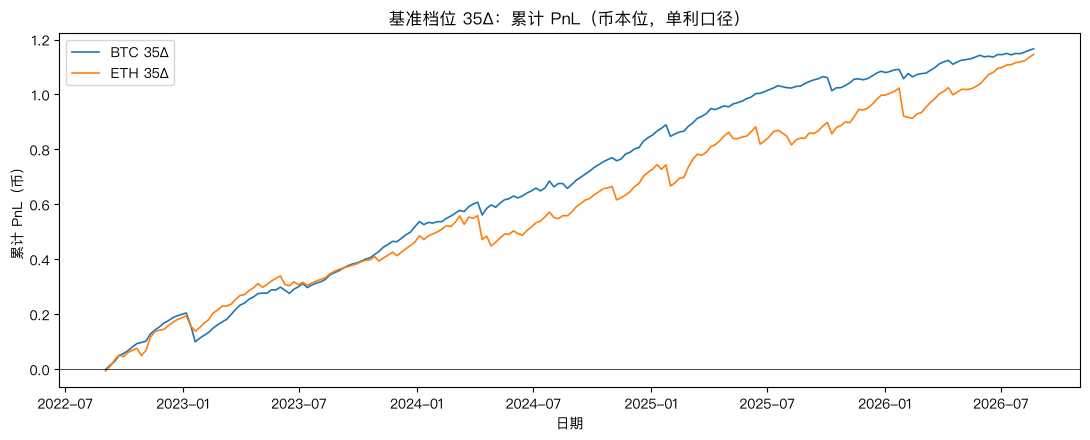

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cur in ("BTC", "ETH"):
    t = trades35[cur]
    ax.plot(pd.to_datetime(t["friday"]), t["pnl"].cumsum(), label=f"{cur} 35Δ", lw=1.2)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("基准档位 35Δ：累计 PnL（币本位，单利口径）")
ax.set_xlabel("日期")
ax.set_ylabel("累计 PnL（币）")
ax.legend()
fig.tight_layout()
plt.show()

权益曲线的形态正是第 1 节的预期：长时间缓慢爬升（每周赚权利金），
间或被几次急跌打断（尾部周末）。注意两个标的的回撤时点高度重合——
打击卖方的是同一批宏观事件，BTC/ETH 双标的不是有效的分散化。

### 4.2 逐笔损益分布：多次小赢、少数大亏

BTC: 盈利周平均 +0.0097（上限约 +0.0269），亏损周平均 -0.0123，最差单周 -0.0596
ETH: 盈利周平均 +0.0124（上限约 +0.0474），亏损周平均 -0.0201，最差单周 -0.1018


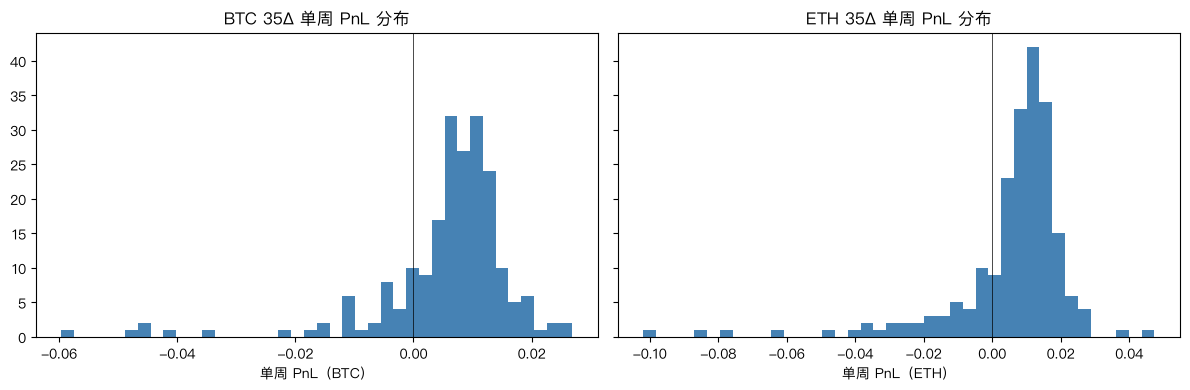

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, cur in zip(axes, ("BTC", "ETH")):
    t = trades35[cur]
    ax.hist(t["pnl"], bins=40, color="steelblue")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{cur} 35Δ 单周 PnL 分布")
    ax.set_xlabel(f"单周 PnL（{cur}）")
    wins, losses = t[t["pnl"] > 0]["pnl"], t[t["pnl"] <= 0]["pnl"]
    print(f"{cur}: 盈利周平均 +{wins.mean():.4f}（上限约 +{wins.max():.4f}），"
          f"亏损周平均 {losses.mean():.4f}，最差单周 {losses.min():.4f}")
fig.tight_layout()
plt.show()

In [10]:
for cur in ("BTC", "ETH"):
    t = trades35[cur]
    worst = t.nsmallest(5, "pnl")[
        ["friday", "spot_ret", "pnl", "C_strike", "P_strike", "C_payoff", "P_payoff"]]
    print(f"\n{cur} 35Δ 最差 5 周（spot_ret = 周末现货涨跌幅）：")
    display(worst.reset_index(drop=True))


BTC 35Δ 最差 5 周（spot_ret = 周末现货涨跌幅）：


,friday,spot_ret,pnl,C_strike,P_strike,C_payoff,P_payoff
0,2023-01-20,0.083129,-0.059611,21250.0,21000.0,0.072361,0.000000
1,2025-10-10,-0.062166,-0.047708,120000.0,118000.0,0.000000,0.056558
2,2024-04-12,-0.068196,-0.046487,70000.0,68500.0,0.000000,0.060737
3,2023-01-13,0.075125,-0.045390,19500.0,19000.0,0.059140,0.000000
4,2025-01-31,-0.054630,-0.042208,106000.0,105000.0,0.000000,0.052958



ETH 35Δ 最差 5 周（spot_ret = 周末现货涨跌幅）：


,friday,spot_ret,pnl,C_strike,P_strike,C_payoff,P_payoff
0,2026-01-30,-0.112905,-0.101847,2750.0,2700.0,0.000000,0.117097
1,2024-04-12,-0.103238,-0.086907,3500.0,3400.0,0.000000,0.102157
2,2025-01-31,-0.098034,-0.076512,3475.0,3375.0,0.000000,0.091262
3,2025-06-20,-0.088010,-0.063538,2525.0,2450.0,0.000000,0.077288
4,2024-11-08,0.085339,-0.048815,2975.0,2900.0,0.067565,0.000000


分布右偏截断、左尾拉长：盈利周的上限就是权利金（卖方收益有顶），
亏损周可以亏掉数十倍单周权利金。注意最差周里 payoff 只在一条腿上出现——
暴涨周末亏 call 腿、暴跌周末亏 put 腿，另一条腿的权利金照收。

### 4.3 十二档 delta 对比

In [11]:
for cur in ("BTC", "ETH"):
    g = grids[cur][["delta", "weeks", "total_pnl_base", "ret_on_notional",
                    "win_rate", "sharpe_w", "max_dd_base", "retained"]]
    print(f"\n{cur}（总 PnL 单位：{cur}）：")
    display(g.style.format({
        "total_pnl_base": "{:.3f}", "ret_on_notional": "{:.2%}",
        "win_rate": "{:.1%}", "sharpe_w": "{:.2f}",
        "max_dd_base": "{:.3f}", "retained": "{:.1%}",
    }).hide(axis="index"))


BTC（总 PnL 单位：BTC）：


delta,weeks,total_pnl_base,ret_on_notional,win_rate,sharpe_w,max_dd_base,retained
0.050000,208,0.202,0.10%,97.6%,4.40,-0.026,72.5%
0.100000,208,0.338,0.16%,96.2%,2.60,-0.046,60.2%
0.150000,208,0.519,0.25%,93.8%,2.74,-0.078,58.6%
0.200000,208,0.699,0.34%,91.3%,3.11,-0.075,57.3%
0.250000,208,0.879,0.42%,86.1%,3.29,-0.084,55.0%
0.300000,208,1.059,0.51%,84.1%,3.48,-0.098,52.1%
0.350000,208,1.166,0.56%,81.2%,3.43,-0.105,47.1%
0.400000,208,1.300,0.62%,80.8%,3.57,-0.099,43.3%
0.450000,208,1.324,0.64%,78.8%,3.40,-0.107,37.0%
0.500000,208,1.342,0.65%,81.7%,3.40,-0.103,31.9%



ETH（总 PnL 单位：ETH）：


delta,weeks,total_pnl_base,ret_on_notional,win_rate,sharpe_w,max_dd_base,retained
0.050000,208,0.162,0.08%,96.6%,1.18,-0.045,44.6%
0.100000,208,0.280,0.13%,95.2%,1.09,-0.073,38.8%
0.150000,208,0.541,0.26%,91.8%,1.85,-0.074,47.2%
0.200000,208,0.645,0.31%,85.1%,1.72,-0.092,39.6%
0.250000,208,0.806,0.39%,84.1%,1.86,-0.106,38.8%
0.300000,208,1.053,0.51%,81.7%,2.30,-0.095,39.4%
0.350000,208,1.146,0.55%,78.8%,2.19,-0.111,34.3%
0.400000,208,1.292,0.62%,78.8%,2.32,-0.113,33.1%
0.450000,208,1.319,0.63%,77.4%,2.23,-0.121,27.9%
0.500000,208,1.360,0.65%,75.5%,2.18,-0.129,24.7%


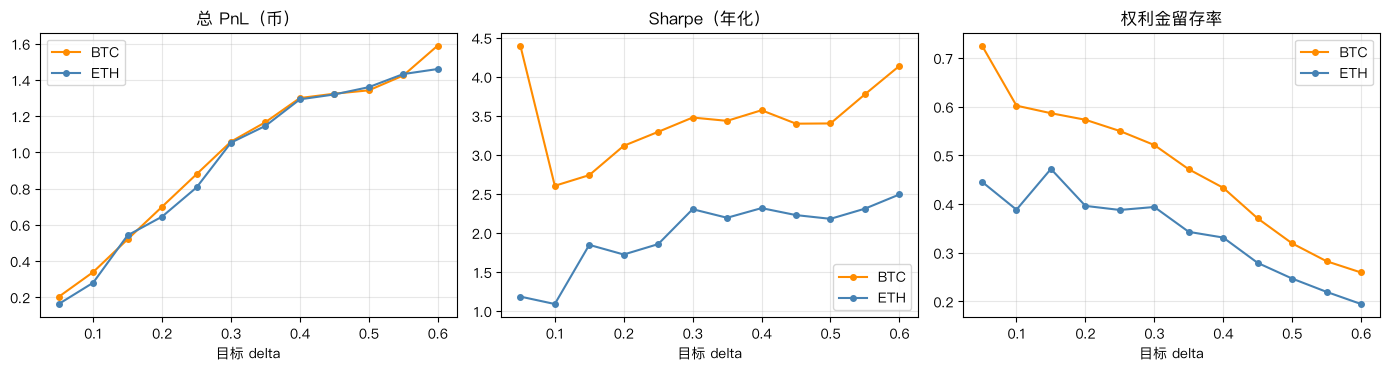

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for cur, color in (("BTC", "darkorange"), ("ETH", "steelblue")):
    g = grids[cur]
    axes[0].plot(g["delta"], g["total_pnl_base"], marker="o", ms=4, label=cur, color=color)
    axes[1].plot(g["delta"], g["sharpe_w"], marker="o", ms=4, label=cur, color=color)
    axes[2].plot(g["delta"], g["retained"], marker="o", ms=4, label=cur, color=color)
for ax, title in zip(axes, ("总 PnL（币）", "Sharpe（年化）", "权利金留存率")):
    ax.set_title(title)
    ax.set_xlabel("目标 delta")
    ax.legend()
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

三句话读完这组图（具体数字见上表）：

- **总 PnL 随 delta 单调上升**：行权价越靠近平值，收的权利金越多。
  但这是"卖更多保险收更多保费"，不是免费午餐——留存率同步大幅下滑。
- **Sharpe 不是单调的**：BTC 呈双峰（极虚值档与高档都好，中间略低），
  ETH 总体随 delta 上行。0.35~0.45 中间档在收益、胜率、留存率之间较均衡，
  这是选 0.35 作基准的理由。
- **胜率随 delta 下行**：越靠近平值越容易被击穿。

## 5. 敏感性分析

三个方向：复利口径、call/put 非对称 delta、回撤事件归因。
逻辑在 `optimize.py`，notebook 直接 import。

### 5.1 复利口径

模型：起始持有 1 单位现货，**每周将全部币本位权益滚入下周名义**——
权益 $B_t$ 对应每周卖 $B_t$ 张 strangle，周收益率 $r_t$ 等于单张币本位 PnL，
故 `equity = Π(1+r_t)`；USD 口径再乘每周现货涨跌，对比纯囤币。

In [13]:
from itertools import product

from optimize import simulate, metrics, drawdown_episodes

# optimize.py import 时又切回了 Agg，再切回 inline
%matplotlib inline

comp35, sym_grids = {}, {}
for cur in ("BTC", "ETH"):
    sym = pd.DataFrame([{"delta": d, **metrics(simulate(weeks[cur], delivery[cur], d, d))}
                        for d in DELTA_GRID])
    sym.to_csv(RESULTS_DIR / f"compound_sym_{cur}.csv", index=False)
    sym_grids[cur] = sym
    t35 = simulate(weeks[cur], delivery[cur], BASE_DELTA, BASE_DELTA)
    comp35[cur] = t35
    m = metrics(t35)
    print(f"{cur} 35Δ 复利口径：期末权益 {m['equity_final']:.2f} 倍（币本位），"
          f"CAGR {m['cagr']:.1%}，Calmar {m['calmar']:.2f}；"
          f"USD 口径 {m['usd_final']:.2f} 倍 vs 囤币 {m['bh_final']:.2f} 倍，"
          f"USD 最大回撤 {m['max_dd_usd']:.1%}")

BTC 35Δ 复利口径：期末权益 3.15 倍（币本位），CAGR 33.3%，Calmar 3.25；USD 口径 4.82 倍 vs 囤币 1.53 倍，USD 最大回撤 -11.2%
ETH 35Δ 复利口径：期末权益 3.03 倍（币本位），CAGR 31.9%，Calmar 2.92；USD 口径 5.17 倍 vs 囤币 1.71 倍，USD 最大回撤 -22.4%


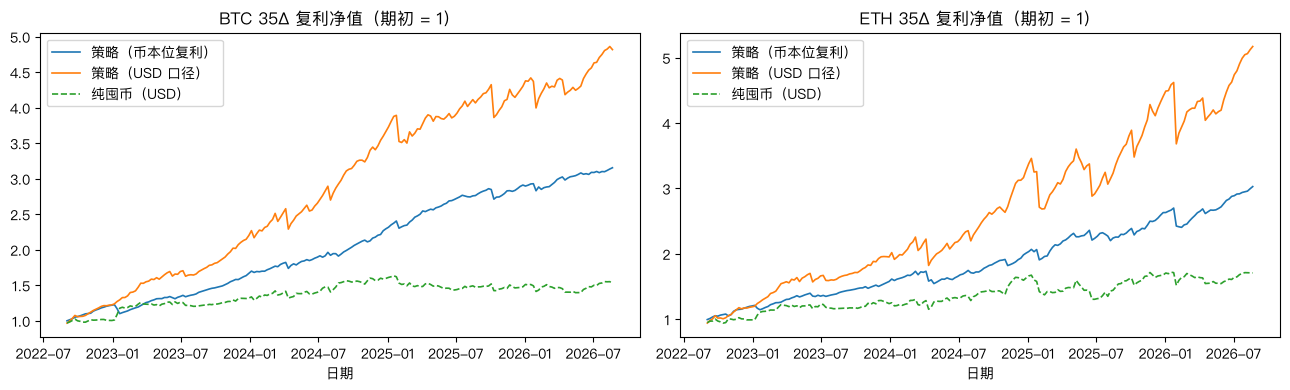

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, cur in zip(axes, ("BTC", "ETH")):
    t = comp35[cur]
    dates = pd.to_datetime(t["friday"])
    ax.plot(dates, (1 + t["ret"]).cumprod().values, label="策略（币本位复利）", lw=1.2)
    ax.plot(dates, ((1 + t["ret"]) * t["spot_ratio"]).cumprod().values,
            label="策略（USD 口径）", lw=1.2)
    ax.plot(dates, t["spot_ratio"].cumprod().values, label="纯囤币（USD）", lw=1.2, ls="--")
    ax.set_title(f"{cur} 35Δ 复利净值（期初 = 1）")
    ax.set_xlabel("日期")
    ax.legend()
fig.tight_layout()
plt.show()

复利显著放大了与囤币的差距（数字见上）。但要注意这个模型假设
每周权利金与赔付可以**无损再投资**为下周名义——实际受合约最小面值
（1 张 = 1 单位标的）和流动性约束，小额资金无法严格复制这条曲线。

### 5.2 非对称 delta：call 与 put 独立选档

对称 strangle 隐含"两侧风险对称"的假设，但样本里暴涨周末和暴跌周末的
频率/幅度并不对称。让 call 腿、put 腿独立选择目标 delta，跑 12×12 = 144
个组合（复利口径），看 CAGR 与 Calmar 的热图。

In [15]:
asym = {}
for cur in ("BTC", "ETH"):
    rows = []
    for dc, dp in product(DELTA_GRID, DELTA_GRID):
        rows.append({"delta_call": dc, "delta_put": dp,
                     **metrics(simulate(weeks[cur], delivery[cur], dc, dp))})
    a = pd.DataFrame(rows)
    a.to_csv(RESULTS_DIR / f"compound_asym_{cur}.csv", index=False)
    asym[cur] = a
    print(f"{cur}: 144 个组合完成")

BTC: 144 个组合完成
ETH: 144 个组合完成


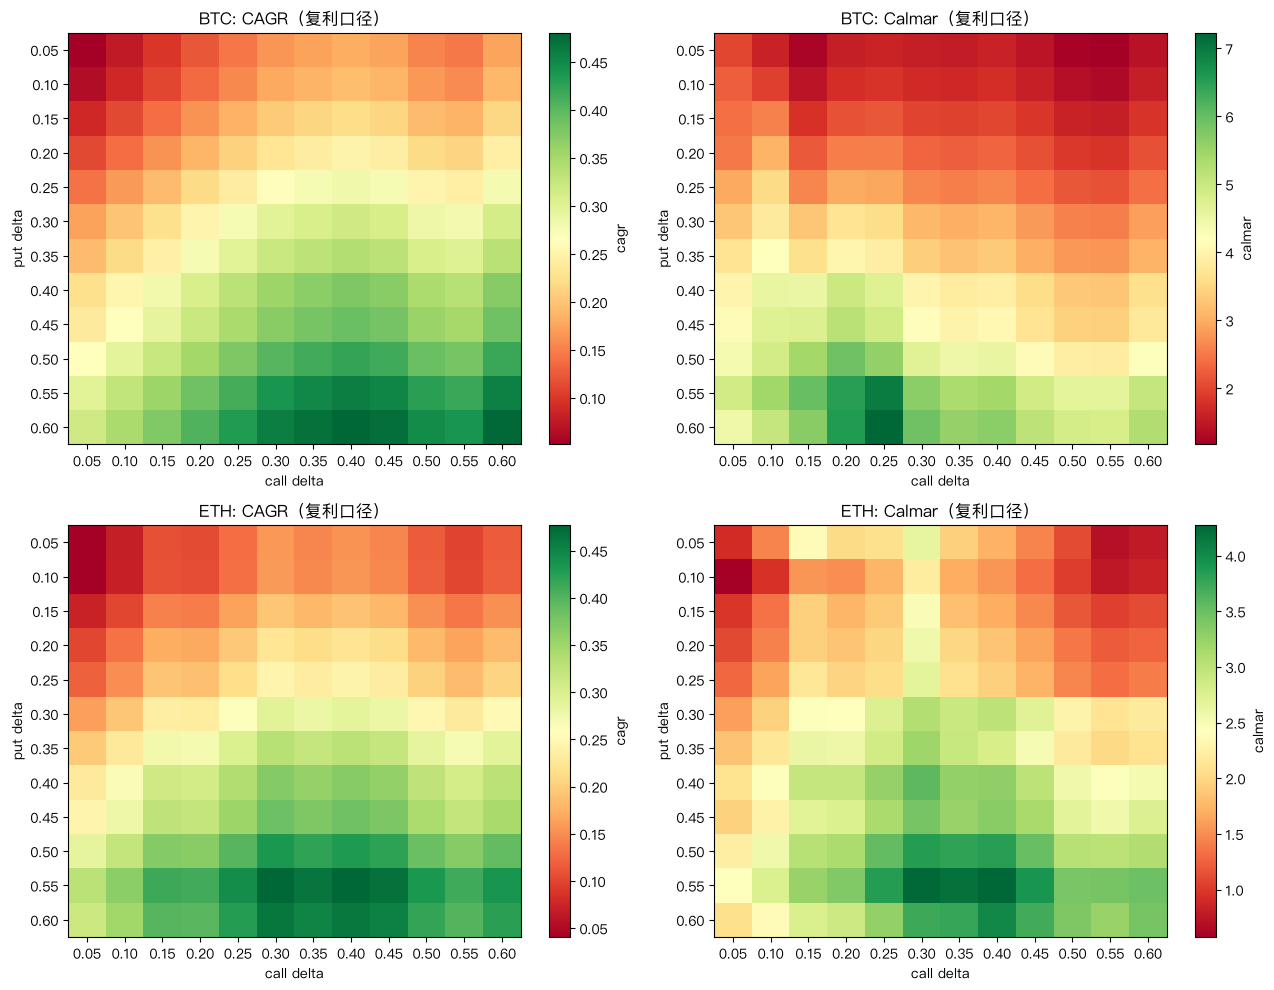

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, cur in enumerate(("BTC", "ETH")):
    for j, (val, title) in enumerate((("cagr", "CAGR"), ("calmar", "Calmar"))):
        piv = asym[cur].pivot(index="delta_put", columns="delta_call", values=val)
        ax = axes[i, j]
        im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto")
        fig.colorbar(im, ax=ax, label=val)
        ax.set_xticks(range(len(piv.columns)), [f"{c:.2f}" for c in piv.columns])
        ax.set_yticks(range(len(piv.index)), [f"{c:.2f}" for c in piv.index])
        ax.set_xlabel("call delta")
        ax.set_ylabel("put delta")
        ax.set_title(f"{cur}: {title}（复利口径）")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "heatmap_asym.png", dpi=120)
plt.show()

In [17]:
for cur in ("BTC", "ETH"):
    top5 = asym[cur].nlargest(5, "calmar")[
        ["delta_call", "delta_put", "cagr", "sharpe_w", "max_dd", "calmar", "win_rate"]]
    print(f"\n{cur} 按 Calmar 排序前五：")
    display(top5.style.format({"cagr": "{:.1%}", "sharpe_w": "{:.2f}",
                               "max_dd": "{:.1%}", "calmar": "{:.2f}",
                               "win_rate": "{:.1%}"}).hide(axis="index"))


BTC 按 Calmar 排序前五：


delta_call,delta_put,cagr,sharpe_w,max_dd,calmar,win_rate
0.250000,0.600000,43.3%,3.42,-6.0%,7.23,76.9%
0.250000,0.550000,41.4%,3.54,-5.9%,6.96,79.3%
0.200000,0.600000,40.7%,3.28,-6.2%,6.55,78.4%
0.200000,0.550000,38.8%,3.40,-6.0%,6.50,81.2%
0.150000,0.550000,35.8%,3.21,-6.0%,6.00,79.8%



ETH 按 Calmar 排序前五：


delta_call,delta_put,cagr,sharpe_w,max_dd,calmar,win_rate
0.400000,0.550000,47.5%,2.58,-11.1%,4.27,80.8%
0.300000,0.550000,47.7%,2.59,-11.2%,4.25,79.3%
0.350000,0.550000,46.5%,2.55,-11.1%,4.20,81.2%
0.400000,0.600000,46.1%,2.56,-11.5%,4.02,80.8%
0.450000,0.550000,46.7%,2.56,-11.9%,3.92,77.4%


读热图的要点（数字见上表）：

- **最优区是平台而非尖点**：BTC 在 call∈[0.15,0.30] × put∈[0.50,0.60]
  整个矩形内都成立；ETH 在 call∈[0.35,0.40] × put=0.55 附近同样平坦。
  选平台中点而非单点，是为了缓解样本内寻优的过拟合。
- **put 侧吃下行偏度溢价**：put 维持高 delta 收更多权利金，
  样本内下行周末的赔付频率低于定价隐含。
- **call 侧降 delta 规避暴涨周末的空头挤压**：样本里几次大回撤中，
  上涨型的亏损全部来自 call 腿，拉低 call delta 直接削弱这类亏损。
- 这些都是 **208 周样本内**观察，不构成样本外保证；
  0.60 是网格边界，"put 越高越好"可能只是边界效应。

### 5.3 回撤事件归因

把 35Δ 对称配置的复利权益切成 peak→trough 区间，看前几大回撤：

In [18]:
for cur in ("BTC", "ETH"):
    ep = drawdown_episodes(comp35[cur])
    ep.to_csv(RESULTS_DIR / f"drawdowns_{cur}_35-35.csv", index=False)
    print(f"\n{cur} 35/35 复利口径前 {len(ep)} 大回撤区间：")
    display(ep.style.format({"depth": "{:.1%}"}).hide(axis="index"))


BTC 35/35 复利口径前 5 大回撤区间：


peak_friday,trough_friday,recovered_friday,depth,weeks_to_trough
2023-01-06,2023-01-20,2023-03-17,-10.2%,2
2025-09-26,2025-10-10,2025-12-05,-5.2%,2
2024-04-05,2024-04-12,2024-05-10,-4.6%,1
2025-01-24,2025-01-31,2025-02-28,-4.2%,1
2026-01-23,2026-01-30,2026-03-13,-3.4%,1



ETH 35/35 复利口径前 5 大回撤区间：


peak_friday,trough_friday,recovered_friday,depth,weeks_to_trough
2026-01-23,2026-02-13,2026-05-22,-10.9%,3
2024-04-05,2024-04-26,2024-07-19,-10.9%,3
2025-01-10,2025-01-31,2025-02-28,-7.8%,3
2025-06-13,2025-08-08,2025-09-26,-6.7%,8
2023-01-06,2023-01-20,2023-02-10,-5.5%,2


对这些区间内的周末逐一做事件调研（据公开市场报道与行情复盘，
逐笔数据交叉验证），**所有大回撤都是"外生冲击 × 周末流动性真空"的组合**：

| 周末（周五入场） | 事件归因 |
|---|---|
| 2023-01-13 / 01-20 | CPI 降温 + FTX 暴雷后修复 + 空头挤压，BTC 两周 17k→23k；亏损全部来自 call 腿 |
| 2024-04-12 | 伊朗首次直接袭击以色列 + 减半前杠杆清洗 |
| 2024-08-02 | 日元套息交易平仓；真正的尾部在**周一**，周日 08:00 结算低估了尾部 |
| 2024-11-08 | 特朗普胜选后的轧空；ETH 亏损全部来自 call 腿 |
| 2025-01-31 | 特朗普首轮关税行政令 |
| 2025-06-20 | 美军轰炸伊朗核设施（周末突发，BTC 已基本收复而 ETH 没有） |
| 2025-10-10 | 特朗普 100% 对华关税威胁，据公开报道全网强平约 $19.3B、为史上最大 |
| 2026-01-30 ~ 02-13 | 日本国债闪崩 + 格陵兰关税争端 + Fed 鹰派 |

共性：地缘与政策冲击偏好周末发生（或周末才传入市场），此时传统市场闭市，
加密是唯一开盘的风险资产——抛压正好落在本策略的持仓窗口。
亏损方向跟随冲击方向；ETH 的尾部约为 BTC 的 1.5~2 倍（非固定比例）。

## 6. 局限性

这份回测在以下方面是**偏乐观**的，解读结果时必须带着这些修正：

- **成交价非买一价**：入场价用小时 K 线开盘价或最近成交价，未考虑买卖价差；
  周末深度薄的虚值期权实际滑点会系统性侵蚀卖方收益。
- **部分入场价陈旧**：一部分腿用了 16:00 前后窗口内的最近成交价
  （最早回退到 12:00），该价格对应的现货与入场时点现货存在偏差。
- **r=0 近似**：40 小时期限下影响很小，但严格说贴现与远期定价被忽略。
- **保证金与资金占用未建模**：short put 腿的保证金要求、资金机会成本未计入。
- **币本位 PnL 的 USD 折算时点**：USD 值按各周入场价折算，仅作量级参考。
- **样本期环境依赖**：2022-09 ~ 2026-08 的 IV 水平与周末波动特征不保证延续；
  若未来 IV 中枢下移或周末极端波动增多，结果会显著不同。
- **行权价宇宙的重建方式**：仅扫描 ±max(12%, 3.2σ√T) 带宽，极端行情周目标
  delta 档可能落在带宽外而选到次优合约。
- **样本内寻优的过拟合**：非对称 delta 的最优参数在同一 208 周样本上选出，
  选"平台"而非单点只能缓解、不能消除过拟合。
- **周日 08:00 结算低估延续到周一的尾部**：如 2024-08 日元套息平仓的主跌段
  发生在周一。回测度量的是"周末窗口"的风险，不是"持仓到周一"的风险。
- **复利模型假设无损再投资**：忽略合约最小面值取整，小额资金无法严格复制。

## 7. 复现方法

**本地**（仓库根目录，环境用 uv 管理）：

```bash
uv sync
cd tasks/0001-weekend-strangle
uv run download_data.py   # 缺数据时从 Deribit 下载；有缓存则跳过
uv run backtest.py        # 12 档 delta × BTC/ETH，写 results/
uv run optimize.py        # 复利 + 非对称网格 + 回撤区间
uv run make_report.py     # 生成 results/report.html
```

数据根目录默认 `/Volumes/trade/data`，可用环境变量 `TRADE_DATA_ROOT` 覆盖。

**Colab**：点顶部 badge 打开本 notebook 直接运行。引导 cell 会检测
`google.colab` 环境，克隆仓库、进入任务目录，数据不存在时自动运行
`download_data.py`（首次下载约数十分钟）。

---

*本 notebook 为研究性回测，所有结果均为历史样本内统计，不构成投资建议。*